# Video import

In [83]:
crop_range = {"top": 870, "bottom": 1000, "left": 120, "right": 1800}

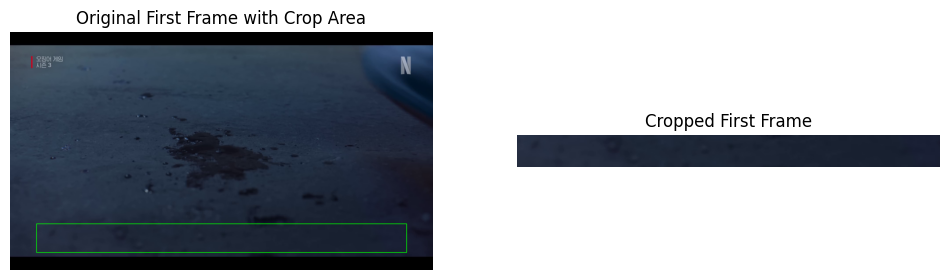

In [99]:
import cv2
import matplotlib.pyplot as plt

video_path = './videos/Squid_game.mp4'
cap = cv2.VideoCapture(video_path)

def load_video(video_path):
    frames = []
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(frame)
    cap.release()
    return frames

def crop_image(image, crop_range):
    top = crop_range["top"]
    bottom = crop_range["bottom"]
    left = crop_range["left"]
    right = crop_range["right"]
    
    return image[top:bottom, left:right]

def crop_video(frames, crop_range):
    top = crop_range["top"]
    bottom = crop_range["bottom"]
    left = crop_range["left"]
    right = crop_range["right"]
    
    cropped_frames = []
    for frame in frames:
        if frame is not None:
            cropped_frame = frame[top:bottom, left:right]
            cropped_frames.append(cropped_frame)
    return cropped_frames

frames = load_video(video_path)
cropped_images = crop_video(frames, crop_range)

# 첫 프레임 시각화 예시
if frames:
    plt.figure(figsize=(12, 5))
    original_frame_with_crop_rect = frames[0].copy()
    cv2.rectangle(original_frame_with_crop_rect, 
                  (crop_range["left"], crop_range["top"]), 
                  (crop_range["right"], crop_range["bottom"]), 
                  (0, 255, 0), 2)
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_frame_with_crop_rect, cv2.COLOR_BGR2RGB))
    plt.title("Original First Frame with Crop Area")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(cropped_images[0], cv2.COLOR_BGR2RGB))
    plt.title(f"Cropped First Frame")
    plt.axis('off')
    plt.show()

# 자막 인식 1: 타겟 픽셀로 타겟 color 지정 > 픽셀 추출

각 프레임에 대해 타겟 color와 똑같으면 픽셀 추출

- images_highlighting_pixel: 프레임별로 detect한 픽셀 모음

In [85]:
target_pixel = (65, 945)
pixel_highlighting_tolerances = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

Target Pixel: (65, 945), Color (RGB): [52 36 28]


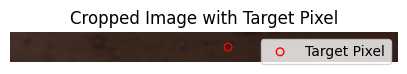

Target Color (RGB): [255, 255, 255]


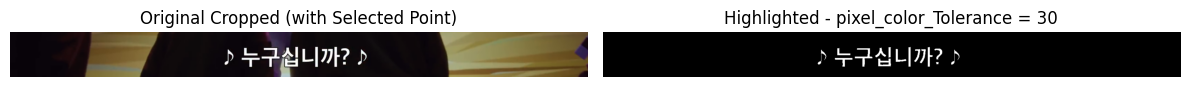

In [86]:
import numpy as np
import matplotlib.pyplot as plt

def get_target_color(cropped_image, target_pixel):
    y, x = target_pixel
    target_color = cropped_image[y, x].astype(int)
    print(f"Target Pixel: {target_pixel}, Color (RGB): {target_color}")

    # 시각화: 선택한 픽셀 위치에 점 표시
    plt.figure(figsize=(5, 5))
    plt.imshow(cropped_image)
    plt.scatter([x], [y], edgecolors='red', facecolors='none', s=30, marker='o', label='Target Pixel')
    plt.title("Cropped Image with Target Pixel")
    plt.legend()
    plt.axis('off')
    plt.show()

    return target_color

def highlight_subtitle_area(cropped_image, target_color, pixel_color_tolerance):
    lower = np.array([max(0, c - pixel_color_tolerance) for c in target_color])
    upper = np.array([min(255, c + pixel_color_tolerance) for c in target_color])

    cropped_bgr = cv2.cvtColor(cropped_image, cv2.COLOR_RGB2BGR)
    lower_bgr = np.array([lower[2], lower[1], lower[0]])
    upper_bgr = np.array([upper[2], upper[1], upper[0]])
    mask = cv2.inRange(cropped_bgr, lower_bgr, upper_bgr)

    highlighted_image = np.full_like(cropped_image, 0)
    highlighted_image[mask == 255] = [255, 255, 255]

    highlight_result = {
        "cropped_image": cropped_image.copy(),
        "highlighted_image": highlighted_image.copy(),
        "pixel_color_tolerance": pixel_color_tolerance,
        "mask": mask.copy(),
        "white_pixel_count": np.sum(mask == 255),
    }
    return highlight_result

def highlight_subtitle_area_with_multi_tolerances(cropped_image, target_color, tolerances):
    results = []
    for tolerance in tolerances:
        result = highlight_subtitle_area(cropped_image, target_color, tolerance)
        results.append(result)
    return results

def visualize_highlight_result(image, target_color, highlighted_image_result):
    print(f"Target Color (RGB): {target_color}")

    # 원본 크롭 이미지 + 점 표시
    plt.figure(figsize=(12, 5)) # figsize 조절 가능
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Cropped (with Selected Point)")
    plt.axis('off')
    # plt.legend(loc='upper right') # 원본 이미지에는 특별한 legend가 없을 수 있으므로 주석 처리 또는 수정
    
    # 단일 하이라이트된 이미지 시각화
    plt.subplot(1, 2, 2)
    plt.imshow(highlighted_image_result["highlighted_image"])
    plt.title(f"Highlighted - pixel_color_Tolerance = {highlighted_image_result['pixel_color_tolerance']}")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

target_color = get_target_color(cropped_images[0], target_pixel)
target_color = [255, 255, 255]

sample_image = cropped_images[170]
sample_highlight_result = highlight_subtitle_area(sample_image, target_color, pixel_color_tolerance=30)
visualize_highlight_result(sample_image, target_color, sample_highlight_result)

highlight_results = highlight_subtitle_area_with_multi_tolerances(sample_image, target_color, pixel_highlighting_tolerances)

# Bounding Box 추출

- target_color
- images_highlighting_pixel: image별로 detect한 픽셀 모음
- all_boxes_per_image: image별로 모든 박스 모음

In [87]:
psm_modes = {
    "psm6": '--oem 3 --psm 6 -l kor+eng',
    "psm8": '--oem 3 --psm 8 -l kor+eng',
    "psm10": '--oem 3 --psm 10 -l kor+eng'
}
conf_thresholds = [0, 10, 50]

총 5개의 박스가 발견되었습니다.


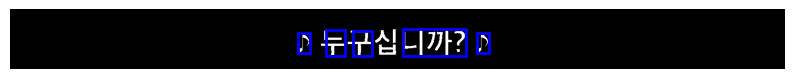

총 368개의 박스가 발견되었습니다.
총 368개의 박스가 발견되었습니다.


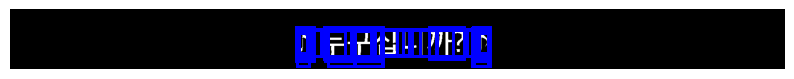

In [88]:
import cv2
import pytesseract
from pytesseract import Output
import matplotlib.pyplot as plt
import numpy as np

pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

def find_boundingbox_from_highlighted_image(highlighted_image, tolerance, psm_mode, conf_threshold):

    gray = cv2.cvtColor(highlighted_image, cv2.COLOR_RGB2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0.01)
    _, binary = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)
    dilated = cv2.dilate(binary, np.ones((2, 2), np.uint8), iterations=1)

    image_height, image_width = dilated.shape

    ocr_result = pytesseract.image_to_data(
        dilated, output_type=Output.DICT, config=psm_mode
    )
    n_boxes = len(ocr_result['level'])
    boxes = []

    for i in range(n_boxes):
        text = ocr_result['text'][i].strip()
        conf = int(ocr_result['conf'][i])
        x = ocr_result['left'][i]
        y = ocr_result['top'][i]
        w = ocr_result['width'][i]
        h = ocr_result['height'][i]

        if (conf > conf_threshold and text and
            x > 0 and y > 0 and x + w < image_width and y + h < image_height):

            boxes.append({
                "tolerance": tolerance,
                "psm_mode": psm_mode,
                "conf_threshold": conf_threshold,
                "x": x,
                "y": y,
                "w": w,
                "h": h,
                "conf": conf,
                "text": text
            })
    return boxes

def find_boundingbox_from_highlighted_results(highlight_results, psm_modes, conf_thresholds):
    all_boxes = []
    for result in highlight_results:
        highlighted_image = result['highlighted_image']
        pixel_color_tolerance = result['pixel_color_tolerance']
        
        for psm_mode in psm_modes:
            for conf_threshold in conf_thresholds:
                boxes = find_boundingbox_from_highlighted_image(
                    highlighted_image, pixel_color_tolerance, psm_modes[psm_mode], conf_threshold
                )
                if boxes:
                    all_boxes.extend(boxes)
    return all_boxes

def visualize_boxes(image, list_of_boxes):
    print(f"총 {len(list_of_boxes)}개의 박스가 발견되었습니다.")
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    ax = plt.gca()

    for box_info in list_of_boxes: # 리스트의 각 박스 정보에 대해 반복
        x = box_info['x']
        y = box_info['y']
        w = box_info['w']
        h = box_info['h']
        text = box_info.get('text', '') # text 키가 없을 경우 빈 문자열
        conf = box_info.get('conf', -1) # conf 키가 없을 경우 -1

        rect = plt.Rectangle((x, y), w, h, fill=False, edgecolor='blue', linewidth=2)
        ax.add_patch(rect)

    plt.axis('off')
    plt.show()

boxes = find_boundingbox_from_highlighted_image(sample_highlight_result['highlighted_image'], sample_highlight_result['pixel_color_tolerance'], '--oem 3 --psm 6 -l kor+eng', 10)
visualize_boxes(sample_highlight_result['highlighted_image'], boxes)
all_boxes = find_boundingbox_from_highlighted_results(highlight_results, psm_modes, conf_thresholds)
print(f"총 {len(all_boxes)}개의 박스가 발견되었습니다.")
visualize_boxes(sample_highlight_result['highlighted_image'], all_boxes)

# Bounding Box 전처리

Bounding box의 경계가 자막에 맞닿도록 처리

총 368개의 박스가 발견되었습니다.


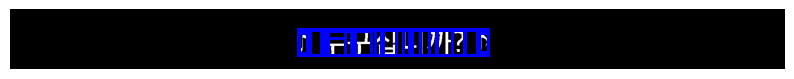

In [90]:
# 색상 유사도 검사 함수
def color_similar(pixel, target_color, tolerance=30):
    pixel = np.array(pixel)
    target_color = np.array(target_color)
    return np.all(np.abs(pixel.astype(int) - target_color.astype(int)) <= tolerance)

def box_trimming(image, box, target_color, box_trimming_tolerance=30):
    x0, y0, w, h = box["x"], box["y"], box["w"], box["h"]
    x_min, y_min, x_max, y_max = x0, y0, x0 + w, y0 + h

    # 이미지 경계에 닿은 박스는 제외
    if x_min == 0 or y_min == 0 or x_max == image.shape[1] or y_max == image.shape[0]:
        return None

    # 위쪽 줄이기
    for yy in range(y_min, y_max):
        line = image[yy, x_min:x_max]
        if np.any([color_similar(px, target_color, box_trimming_tolerance) for px in line]):
            y_min = yy
            break

    # 아래쪽 줄이기
    for yy in range(y_max-1, y_min-1, -1):
        line = image[yy, x_min:x_max]
        if np.any([color_similar(px, target_color, box_trimming_tolerance) for px in line]):
            y_max = yy + 1
            break

    # 왼쪽 줄이기
    for xx in range(x_min, x_max):
        col = image[y_min:y_max, xx]
        if np.any([color_similar(px, target_color, box_trimming_tolerance) for px in col]):
            x_min = xx
            break

    # 오른쪽 줄이기
    for xx in range(x_max-1, x_min-1, -1):
        col = image[y_min:y_max, xx]
        if np.any([color_similar(px, target_color, box_trimming_tolerance) for px in col]):
            x_max = xx + 1
            break

    # 최소 크기 보장
    if x_max > x_min and y_max > y_min:
        trimmed_box = box.copy()
        trimmed_box["x"] = x_min
        trimmed_box["y"] = y_min
        trimmed_box["w"] = x_max - x_min
        trimmed_box["h"] = y_max - y_min
    
    return trimmed_box

def boxes_trimming(image, all_boxes, target_color, box_trimming_tolerance=30):
    trimmed_boxes = []
    for box in all_boxes:
        trimmed_box = box_trimming(image, box, target_color, box_trimming_tolerance)
        if trimmed_box is not None:
            trimmed_boxes.append(trimmed_box)
    return trimmed_boxes

trimmed_boxes = boxes_trimming(sample_highlight_result['highlighted_image'], all_boxes, target_color, box_trimming_tolerance=30)
visualize_boxes(sample_highlight_result['highlighted_image'], trimmed_boxes)

# Y축 길이에 맞춰 histogram 그리기

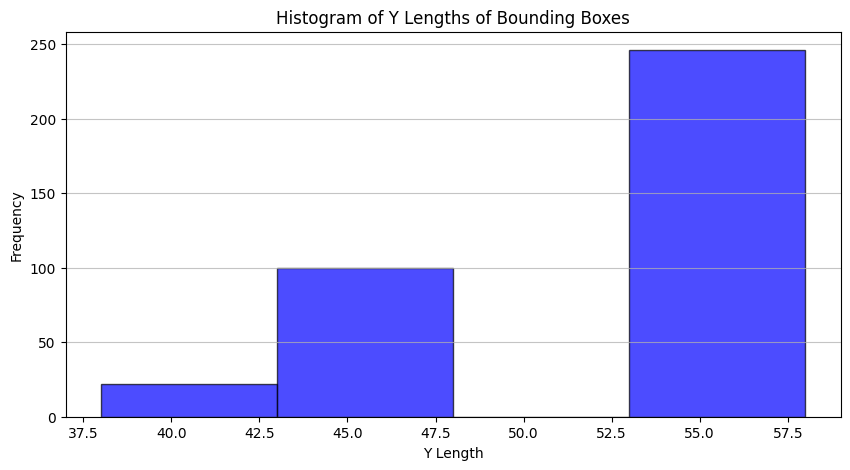

최빈 y 길이 범위: (np.int64(53), np.int64(58)), 개수: 246
총 246개의 박스가 발견되었습니다.


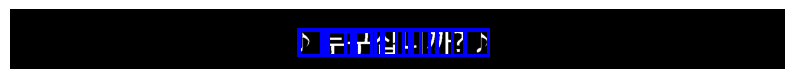

In [91]:
def histogram_ylength(boxes):
    y_lengths = [box['h'] for box in boxes]
    bin_width = 5
    min_val = np.min(y_lengths)
    max_val = np.max(y_lengths)
    bins = np.arange(min_val, max_val + bin_width, bin_width)

    plt.figure(figsize=(10, 5))
    plt.hist(y_lengths, bins=bins, color='blue', alpha=0.7, edgecolor='black')
    plt.title('Histogram of Y Lengths of Bounding Boxes')
    plt.xlabel('Y Length')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

def find_ylength_mode_boxes(boxes):
    y_lengths = [box['h'] for box in boxes]
    bin_width = 5
    min_val = np.min(y_lengths)
    max_val = np.max(y_lengths)
    bins = np.arange(min_val, max_val + bin_width, bin_width)
    
    # 최빈 bin 찾기
    hist, bin_edges = np.histogram(y_lengths, bins=bins)
    mode_index = np.argmax(hist)

    # 최빈 bin에 속하는 box만 추출
    mode_bin = (bin_edges[mode_index], bin_edges[mode_index + 1])
    mode_boxes = [box for box in boxes if mode_bin[0] <= box['h'] < mode_bin[1]]
    print(f"최빈 y 길이 범위: {mode_bin}, 개수: {len(mode_boxes)}")
    return mode_boxes

histogram_ylength(trimmed_boxes)
mode_boxes = find_ylength_mode_boxes(trimmed_boxes)

visualize_boxes(sample_highlight_result['highlighted_image'], mode_boxes)

# 최종 자막 pixel 추출

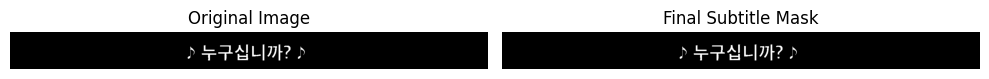

In [92]:
def get_final_bounding_box(boxes):
    x_min = min(box['x'] for box in boxes)
    y_min = min(box['y'] for box in boxes)
    x_max = max(box['x'] + box['w'] for box in boxes)
    y_max = max(box['y'] + box['h'] for box in boxes)

    final_box = {
        "x": x_min,
        "y": y_min,
        "w": x_max - x_min,
        "h": y_max - y_min
    }
    return final_box

def get_final_subtitle_mask(highlighted_image, final_box):
    mask = np.zeros((highlighted_image.shape[0], highlighted_image.shape[1]), dtype=np.uint8)

    # 최종 박스 영역 좌표 추출
    x0, y0, w, h = final_box["x"], final_box["y"], final_box["w"], final_box["h"]
    x1, y1 = x0 + w, y0 + h

    roi_highlighted = highlighted_image[y0:y1, x0:x1]
    white_pixels_condition = np.all(roi_highlighted == [255, 255, 255], axis=2)
    mask[y0:y1, x0:x1][white_pixels_condition] = 255
    
    return mask

def visualize_final_mask(image, mask):
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap='gray')
    plt.title("Final Subtitle Mask")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

final_bounding_box = get_final_bounding_box(mode_boxes)
final_subtitle_mask = get_final_subtitle_mask(sample_highlight_result['highlighted_image'], final_bounding_box)
visualize_final_mask(sample_highlight_result['highlighted_image'], final_subtitle_mask)

# 총정리

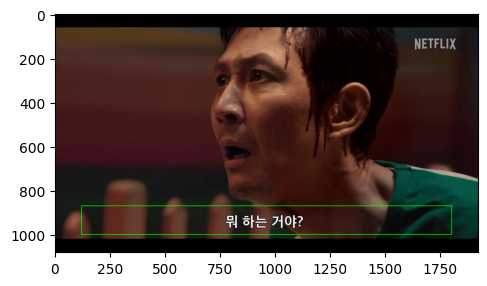

In [106]:
crop_range = {"top": 870, "bottom": 1000, "left": 120, "right": 1800}
target_pixel = (65, 945)

## target_color = get_target_color(cropped_images[0], target_pixel)
target_color = [255, 255, 255]

pixel_highlighting_tolerances = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]

psm_modes = {
    "psm6": '--oem 3 --psm 6 -l kor+eng',
    "psm8": '--oem 3 --psm 8 -l kor+eng',
    "psm10": '--oem 3 --psm 10 -l kor+eng'
}
conf_thresholds = [0, 10, 50]

plt.figure(figsize=(12, 5))
original_frame_with_crop_rect = frames[1100].copy()
cv2.rectangle(original_frame_with_crop_rect, 
                (crop_range["left"], crop_range["top"]), 
                (crop_range["right"], crop_range["bottom"]), 
                (0, 255, 0), 2)
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(original_frame_with_crop_rect, cv2.COLOR_BGR2RGB))

총 277개의 박스가 발견되었습니다.


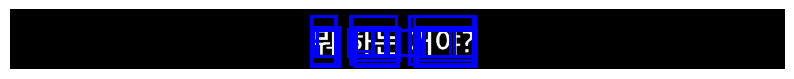

총 277개의 박스가 발견되었습니다.


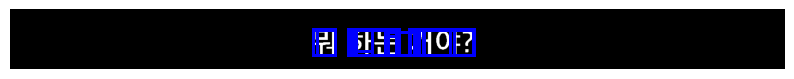

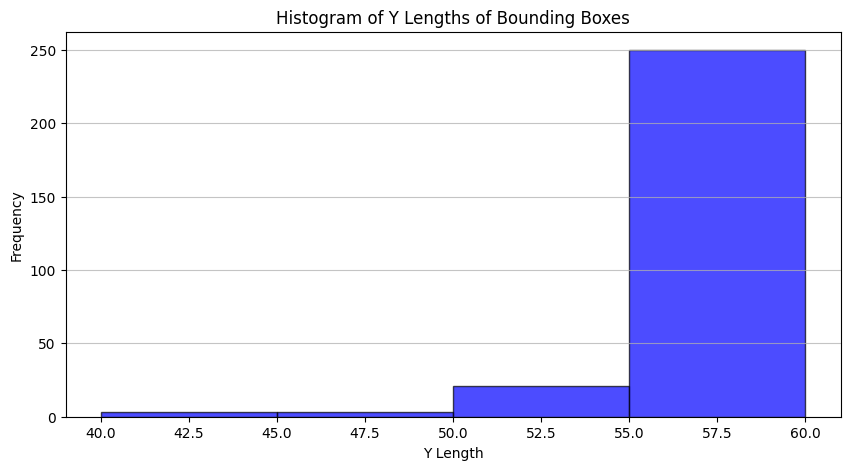

최빈 y 길이 범위: (np.int64(55), np.int64(60)), 개수: 250
총 250개의 박스가 발견되었습니다.


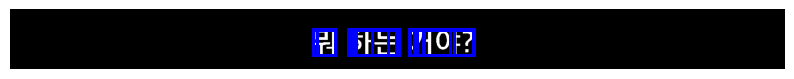

총 1개의 박스가 발견되었습니다.


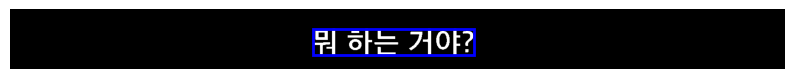

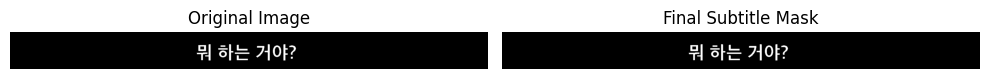

In [107]:
def extract_subtitle_pixel_from_image(image, target_color):
    highlight_results = highlight_subtitle_area_with_multi_tolerances(image, target_color, pixel_highlighting_tolerances)
    highlighted_image = highlight_results[9]['highlighted_image']
    all_boxes = find_boundingbox_from_highlighted_results(highlight_results, psm_modes, conf_thresholds)
    visualize_boxes(highlighted_image, all_boxes)
    
    trimmed_boxes = boxes_trimming(highlighted_image, all_boxes, target_color, box_trimming_tolerance=30)
    visualize_boxes(highlighted_image, trimmed_boxes)
    
    histogram_ylength(trimmed_boxes)
    mode_boxes = find_ylength_mode_boxes(trimmed_boxes)
    visualize_boxes(highlighted_image, mode_boxes)

    final_bounding_box = get_final_bounding_box(mode_boxes)
    visualize_boxes(highlighted_image, [final_bounding_box])

    final_subtitle_mask = get_final_subtitle_mask(highlighted_image, final_bounding_box)
    visualize_final_mask(highlighted_image, final_subtitle_mask)

extract_subtitle_pixel_from_image(cropped_images[1100], target_color)